In [1]:
import os
import calendar
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from scipy.spatial import KDTree
from datetime import date

In [2]:
# ===== USER CONFIGURATION =====

# --- Paths ---
data_path  = os.path.expanduser('../test-data/v3.LR.historical_seaIceRIO_ensembleStats')
mesh_file  = os.path.expanduser('../test-data/mpaso-IcoswISC30E3r5-restart.nc')
route_file = os.path.expanduser('../test-data/arctic_route_sections.nc')
output_dir = os.path.expanduser('../figures')

# --- Vessel types to process ---
# Available: 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7',
#            'IA', 'IAsuper', 'IB', 'IC', 'NIS'
vessel_classes = ['NIS']

# --- Route sections to concatenate, in order ---
# Available sections: A through J (as defined in arctic_route_sections.nc)
route_sections = ['E', 'J', 'C', 'D']
# route_sections = ['H', 'I', 'B', 'A']

# --- Years to include (as strings) ---
year_start = 2020
year_end = 2029
years = [str(y) for y in range(year_start, year_end+1)]

# --- Plot mode ---
# 'transit_time' : transit time in days (NaN = impassable)
# 'RIO'          : minimum RIO along the route (NaN = no data)
# 'passability'  : binary green (passable) / red (impassable)
#plot_mode = 'transit_time'
plot_mode = 'RIO'
# plot_mode = 'passability'

# --- Output ---
save_figs = True   # set False to suppress file saving

# --- RIO heatmap summary method ---
# Controls what value is shown in RIO heatmaps. Passability always uses min.
# 'min'  : route-minimum RIO (worst bottleneck along the route)
# 'mean' : route-mean RIO (average ice severity experienced along the transit)
rio_summary_method = 'min'

# --- x-axis centering ---
# 0-based day-of-year to place at the centre of the heatmap x-axis.
# 258 ~ September 16, near the annual Arctic sea-ice minimum.
plot_center_doy = 258

# --- Spatial interpolation ---
# Number of nearest MPAS mesh cells to average RIO over at each route waypoint
k_neighbors = 4

# --- Trend analysis ---
# Ensemble statistic to analyse.  Options: 'median', '5th_percentile', '95th_percentile'
trend_stat             = 'median'
# RIO threshold for detecting spring/fall transitions.
# Spring: first day RIO >= threshold (route opens as ice retreats)
# Fall:   last  day RIO >= threshold (route closes as ice advances)
trend_threshold_rio    = 0
# Rolling-average window (days) applied to each year before threshold detection
trend_rolling_window   = 7
# DOY search windows (0-based): spring opening and fall closing
# trend_spring_doy_range = (60, 180)    # roughly Mar–Jun
#trend_spring_doy_range = (121, 182)    # roughly May–July
trend_spring_doy_range   = (166, 227)   # roughly mid-June through mid-Aug
# trend_fall_doy_range   = (243, 335)   # roughly Sep–Dec
trend_fall_doy_range   = (305, 365)   # roughly Nov–Jan
# Output directory for trend scatter plots.
# Set to a different path here to redirect figures without changing output_dir.
trend_output_dir       = output_dir
# Y-axis limits for trend scatter plots.
# None = auto-fit each panel to its data range (with 14-day padding on each side).
# Set to a (min_doy, max_doy) tuple to fix both panels to the same range,
# e.g. trend_scatter_ylim = (150, 365) to show only Jun–Dec.
trend_scatter_ylim     = None


In [3]:
# Speed and impassability configuration per vessel class.
#   'normal_kt'     : service speed in open water / low-risk conditions (knots)
#   'restricted_kt' : speed in the elevated-risk band (PC* only); None = no restricted band
#   'impass_thresh' : RIO below this value -> segment is impassable
VESSEL_CONFIG = {
    'PC1':     {'normal_kt': 19.0,  'restricted_kt': 11.0, 'impass_thresh': -10},
    'PC2':     {'normal_kt': 16.5,  'restricted_kt':  8.0, 'impass_thresh': -10},
    'PC3':     {'normal_kt': 16.0,  'restricted_kt':  5.0, 'impass_thresh': -10},
    'PC4':     {'normal_kt': 15.0,  'restricted_kt':  5.0, 'impass_thresh': -10},
    'PC5':     {'normal_kt': 14.0,  'restricted_kt':  5.0, 'impass_thresh': -10},
    'PC6':     {'normal_kt': 14.0,  'restricted_kt':  3.0, 'impass_thresh': -10},
    'PC7':     {'normal_kt': 14.0,  'restricted_kt':  3.0, 'impass_thresh': -10},
    'IAsuper': {'normal_kt': 14.0,  'restricted_kt': None, 'impass_thresh':   0},
    'IA':      {'normal_kt': 14.0,  'restricted_kt': None, 'impass_thresh':   0},
    'IB':      {'normal_kt': 14.0,  'restricted_kt': None, 'impass_thresh':   0},
    'IC':      {'normal_kt': 14.0,  'restricted_kt': None, 'impass_thresh':   0},
    'NIS':     {'normal_kt': 14.0,  'restricted_kt': None, 'impass_thresh':   0},
}


def rio_to_speed_array(rio_arr, vessel_class):
    """
    Map an array of per-waypoint RIO values to an array of speeds (knots).

    Waypoints that are impassable (RIO < impass_thresh) receive NaN.
    Non-PC vessels have no restricted band: they sail at normal_kt or are
    impassable.

    Parameters
    ----------
    rio_arr      : ndarray, shape (n_waypoints,)
    vessel_class : str   key into VESSEL_CONFIG

    Returns
    -------
    speed : ndarray, shape (n_waypoints,)  in knots; NaN where impassable
    """
    cfg   = VESSEL_CONFIG[vessel_class]
    speed = np.full(len(rio_arr), np.nan, dtype=float)
    thresh = cfg['impass_thresh']

    passable   = (~np.isnan(rio_arr)) & (rio_arr >= thresh)
    normal     = passable & (rio_arr >= 0)
    restricted = passable & (rio_arr < 0)

    speed[normal] = cfg['normal_kt']
    if cfg['restricted_kt'] is not None:
        speed[restricted] = cfg['restricted_kt']
    else:
        # non-PC: no restricted band — sail at normal speed when passable
        speed[restricted] = cfg['normal_kt']

    return speed


def integrate_transit_time(wp_rio, seg_dist_nm, vessel_class):
    """
    Compute segment-integrated transit time in days.

    Each waypoint is assigned a local speed based on its RIO value.
    Transit time = sum(seg_dist_i / speed_i) / 24.
    Returns NaN if any waypoint along the route is impassable.

    Parameters
    ----------
    wp_rio        : ndarray (n_waypoints,)  per-waypoint RIO (k-neighbour average)
    seg_dist_nm   : ndarray (n_waypoints,)  distance represented by each waypoint (NM)
    vessel_class  : str

    Returns
    -------
    float : transit time in days, or NaN if route is impassable
    """
    speed = rio_to_speed_array(wp_rio, vessel_class)
    if np.any(np.isnan(speed)):
        return np.nan
    return float(np.sum(seg_dist_nm / speed) / 24.0)


In [4]:
print('Loading MPAS mesh...')
ds_mesh = xr.open_dataset(mesh_file)

rad2deg       = 180.0 / np.pi
lat_mesh_full = ds_mesh.latCell.values * rad2deg
lon_mesh_full = ds_mesh.lonCell.values * rad2deg

# Normalise longitudes to [-180, 180]
lon_mesh_full = np.where(lon_mesh_full > 180.0,
                         lon_mesh_full - 360.0,
                         lon_mesh_full)

# Restrict to cells at or north of 60 deg N
ind_north = np.where(lat_mesh_full >= 60.0)[0]
lat_mesh  = lat_mesh_full[ind_north]
lon_mesh  = lon_mesh_full[ind_north]

print(f'  Total mesh cells  : {len(lat_mesh_full):,}')
print(f'  Cells >= 60 deg N : {len(lat_mesh):,}')

Loading MPAS mesh...
  Total mesh cells  : 465,044
  Cells >= 60 deg N : 22,076


In [5]:
print('Loading route sections...')
ds_route = xr.open_dataset(route_file)

trans_lat_list  = []
trans_lon_list  = []
seg_dist_list   = []   # differential distance per waypoint (NM)

for sec in route_sections:
    s = sec.upper()
    dis = ds_route[f'dis_{s}'].values   # cumulative distance (NM), starts at 0
    trans_lat_list.append(ds_route[f'lat_{s}'].values)
    trans_lon_list.append(ds_route[f'lon_{s}'].values)
    # np.diff gives the inter-waypoint spacing; prepend=0 so that the first
    # waypoint of each section contributes dis[0] NM (which is 0 by convention)
    seg_dist_list.append(np.diff(dis, prepend=0.0))

trans_lat    = np.concatenate(trans_lat_list)
trans_lon    = np.concatenate(trans_lon_list)
seg_dist_nm  = np.concatenate(seg_dist_list)   # (n_waypoints,)
total_dist_nm = sum(
    float(np.max(ds_route[f'dis_{s.upper()}'].values)) for s in route_sections
)
route_label  = ''.join(s.upper() for s in route_sections)

print(f'  Sections        : {route_sections}  ->  {len(trans_lat)} waypoints')
print(f'  Total distance  : {total_dist_nm:.1f} nm')
print(f'  seg_dist_nm     : min={seg_dist_nm.min():.3f}, max={seg_dist_nm.max():.3f}, sum={seg_dist_nm.sum():.1f} nm')

# Build KDTree over the northern-hemisphere restricted mesh
print('Building KDTree...')
tree = KDTree(list(zip(lon_mesh, lat_mesh)))
_, inds = tree.query(list(zip(trans_lon, trans_lat)), k=k_neighbors)
print(f'  KDTree ready.  Neighbor index array shape: {inds.shape}')


Loading route sections...
  Sections        : ['E', 'J', 'C', 'D']  ->  4216 waypoints
  Total distance  : 4197.6 nm
  seg_dist_nm     : min=0.000, max=1.000, sum=4197.6 nm
Building KDTree...
  KDTree ready.  Neighbor index array shape: (4216, 4)


In [ ]:
# # ===== USER CONFIGURATION (text-file route) =====
# # Path to the plain-text waypoint file.
# # Format: one waypoint per line ->  lat_deg, lon_deg, cumulative_dist_nm
# # Lines beginning with '#' are treated as comments and ignored.
# # 'cumulative_dist_nm' is the odometer distance from the start of the route (NM),
# # i.e. each row's value is the total distance travelled so far, not the leg length.
# # Example line:  75.1234, 45.1234, 100.0
# route_file_txt = os.path.expanduser('../test-data/text_route3.txt')
# route_label    = os.path.splitext(os.path.basename(route_file_txt))[0]  # or set manually, e.g. 'MYROUTE'

# # ---- load waypoints ----
# print(f'Loading route from {route_file_txt} ...')

# wp_lat_list  = []
# wp_lon_list  = []
# wp_dist_list = []

# with open(route_file_txt) as f:
#     for line in f:
#         line = line.strip()
#         if not line or line.startswith('#'):
#             continue
#         parts = [p.strip() for p in line.split(',')]
#         if len(parts) < 3:
#             continue
#         wp_lat_list.append(float(parts[0]))
#         wp_lon_list.append(float(parts[1]))
#         wp_dist_list.append(float(parts[2]))

# trans_lat  = np.array(wp_lat_list)
# trans_lon  = np.array(wp_lon_list)
# cumul_dist = np.array(wp_dist_list)

# # Differential distance per waypoint (NM) — same convention as the netCDF loader.
# # np.diff with prepend=0 assigns each waypoint the spacing since the previous one;
# # the first waypoint gets cumul_dist[0] (typically 0).
# seg_dist_nm   = np.diff(cumul_dist, prepend=0.0)
# total_dist_nm = float(np.max(cumul_dist))

# print(f'  Waypoints       : {len(trans_lat)}')
# print(f'  Total distance  : {total_dist_nm:.1f} nm')
# print(f'  seg_dist_nm     : min={seg_dist_nm.min():.3f}, max={seg_dist_nm.max():.3f}, sum={seg_dist_nm.sum():.1f} nm')
# print(f'  Route label     : {route_label}')

# # Build KDTree over the northern-hemisphere restricted mesh
# print('Building KDTree...')
# tree = KDTree(list(zip(lon_mesh, lat_mesh)))
# _, inds = tree.query(list(zip(trans_lon, trans_lat)), k=k_neighbors)
# print(f'  KDTree ready.  Neighbor index array shape: {inds.shape}')

In [6]:
def _doy_index(year, month, day):
    """Return 0-based day-of-year index (0 = Jan 1)."""
    return (date(year, month, day) - date(year, 1, 1)).days


def _find_files(vessel_class, years, data_path):
    """Return sorted list of (year, month, filepath) tuples for available monthly files."""
    prefix  = (f'v3.LR.historical_{vessel_class}_EnsStats'
               f'.mpassi.hist.am.timeSeriesStatsDaily.')
    records = []
    for yr in years:
        for mo in range(1, 13):
            fname = os.path.join(data_path, f'{prefix}{yr}-{mo:02d}-01.nc')
            if os.path.exists(fname):
                records.append((int(yr), mo, fname))
    return records


# ---- Read and cache raw RIO data (run once) ----
# raw_rio_data[vessel_class] holds a list of (year, month, rio_med_arr, rio_5th_arr, rio_95th_arr)
# where each array has shape (n_days_in_month, n_arctic_cells).
raw_rio_data = {}

for vessel_class in vessel_classes:
    print(f'\n===== {vessel_class} =====')
    file_records = _find_files(vessel_class, years, data_path)

    if not file_records:
        print(f'  WARNING: no files found for {vessel_class} in the specified years -- skipping.')
        continue

    cached_months = []
    for yr, mo, fpath in file_records:
        print(f'  {os.path.basename(fpath)}')
        ds = xr.open_dataset(fpath)

        rio_med_arr  = ds['timeDaily_avg_RIO_ensembleMedian'].values
        rio_5th_arr  = ds['timeDaily_avg_RIO_ensemble5th'].values
        rio_95th_arr = ds['timeDaily_avg_RIO_ensemble95th'].values
        ds.close()

        cached_months.append((yr, mo, rio_med_arr, rio_5th_arr, rio_95th_arr))

    raw_rio_data[vessel_class] = cached_months
    print(f'  Done. {len(cached_months)} file(s) cached.')

print('\nRaw data read complete.')


===== NIS =====
  v3.LR.historical_NIS_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-01-01.nc
  v3.LR.historical_NIS_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-02-01.nc
  v3.LR.historical_NIS_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-03-01.nc
  v3.LR.historical_NIS_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-04-01.nc
  v3.LR.historical_NIS_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-05-01.nc
  v3.LR.historical_NIS_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-06-01.nc
  v3.LR.historical_NIS_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-07-01.nc
  v3.LR.historical_NIS_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-08-01.nc
  v3.LR.historical_NIS_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-09-01.nc
  v3.LR.historical_NIS_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-10-01.nc
  v3.LR.historical_NIS_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-11-01.nc
  v3.LR.historical_NIS_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-12-01.nc

In [7]:
# ---- Route-specific extraction (re-run after changing route/waypoints) ----
# Uses: raw_rio_data, inds, seg_dist_nm, rio_summary_method, vessel_classes
results = {}

for vessel_class in vessel_classes:
    if vessel_class not in raw_rio_data:
        print(f'  WARNING: no cached data for {vessel_class} -- skipping.')
        continue

    cached_months = raw_rio_data[vessel_class]
    print(f'\n===== {vessel_class}: extracting route metrics =====')

    avail_years  = sorted(set(yr for yr, _, __, ___, ____ in cached_months))
    n_years      = len(avail_years)
    year_idx_map = {yr: i for i, yr in enumerate(avail_years)}

    shape            = (n_years, 366)
    min_rio_med      = np.full(shape, np.nan)
    min_rio_5th      = np.full(shape, np.nan)
    min_rio_95th     = np.full(shape, np.nan)
    summary_rio_med  = np.full(shape, np.nan)
    summary_rio_5th  = np.full(shape, np.nan)
    summary_rio_95th = np.full(shape, np.nan)
    tt_med           = np.full(shape, np.nan)
    tt_5th           = np.full(shape, np.nan)
    tt_95th          = np.full(shape, np.nan)

    for yr, mo, rio_med_arr, rio_5th_arr, rio_95th_arr in cached_months:
        n_days = rio_med_arr.shape[0]
        yi     = year_idx_map[yr]

        for day_idx in range(n_days):
            doy = _doy_index(yr, mo, day_idx + 1)   # 0-based day-of-year

            # Average k neighbours at each route waypoint: shape (n_waypoints,)
            wp_rio_med  = np.mean(rio_med_arr [day_idx, inds], axis=1)
            wp_rio_5th  = np.mean(rio_5th_arr [day_idx, inds], axis=1)
            wp_rio_95th = np.mean(rio_95th_arr[day_idx, inds], axis=1)

            # Route-minimum RIO (always stored; used for passability)
            min_rio_med [yi, doy] = float(np.nanmin(wp_rio_med))
            min_rio_5th [yi, doy] = float(np.nanmin(wp_rio_5th))
            min_rio_95th[yi, doy] = float(np.nanmin(wp_rio_95th))

            # Summary RIO (method-controlled; used for RIO heatmap)
            if rio_summary_method == 'mean':
                summary_rio_med [yi, doy] = float(np.nanmean(wp_rio_med))
                summary_rio_5th [yi, doy] = float(np.nanmean(wp_rio_5th))
                summary_rio_95th[yi, doy] = float(np.nanmean(wp_rio_95th))
            else:  # 'min'
                summary_rio_med [yi, doy] = float(np.nanmin(wp_rio_med))
                summary_rio_5th [yi, doy] = float(np.nanmin(wp_rio_5th))
                summary_rio_95th[yi, doy] = float(np.nanmin(wp_rio_95th))

            # Segment-integrated transit time
            tt_med [yi, doy] = integrate_transit_time(wp_rio_med,  seg_dist_nm, vessel_class)
            tt_5th [yi, doy] = integrate_transit_time(wp_rio_5th,  seg_dist_nm, vessel_class)
            tt_95th[yi, doy] = integrate_transit_time(wp_rio_95th, seg_dist_nm, vessel_class)

    results[vessel_class] = {
        'years':             avail_years,
        'min_rio_med':       min_rio_med,
        'min_rio_5th':       min_rio_5th,
        'min_rio_95th':      min_rio_95th,
        'summary_rio_med':   summary_rio_med,
        'summary_rio_5th':   summary_rio_5th,
        'summary_rio_95th':  summary_rio_95th,
        'tt_med':            tt_med,
        'tt_5th':            tt_5th,
        'tt_95th':           tt_95th,
    }
    print(f'  Done. {n_years} year(s), {len(cached_months)} file(s) processed.')

print('\nRoute extraction complete.')


===== NIS: extracting route metrics =====
  Done. 10 year(s), 120 file(s) processed.

Route extraction complete.


In [8]:
# Month start positions (0-based day-of-year) and labels for x-axis ticks
_MONTH_DOY   = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
_MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


def make_heatmap(data, years, vessel_class, stat_label, plot_mode,
                 route_label, save_figs, output_dir, total_dist_nm=None,
                 center_doy=258, rio_summary_method='min',
                 trend_overlay=None):
    """
    Produce a single heatmap figure.

    Parameters
    ----------
    data               : ndarray, shape (n_years, 366)
                         transit_time mode : transit times in days (NaN = impassable)
                         RIO / passability : minimum or summary RIO values
    years              : list of int
    vessel_class       : str
    stat_label         : str   e.g. 'Median', '5th percentile'
    plot_mode          : str   'transit_time', 'RIO', or 'passability'
    route_label        : str   e.g. 'HIBA'
    save_figs          : bool
    output_dir         : str
    total_dist_nm      : float  total route length in nautical miles
    center_doy         : int    0-based DOY to place at the centre of the x-axis
    rio_summary_method : str    'min' or 'mean'; used for RIO colorbar label
    trend_overlay      : dict or None
                         If provided, overlays threshold-crossing scatter points
                         and trend lines on the heatmap.  Expected keys:
                           'spring' and/or 'fall', each a dict with:
                             'yi'        – ndarray of year indices with valid crossings
                             'rolled_x'  – corresponding rolled x-axis positions
                             'slope'     – trend slope (days / year)
                             'intercept' – trend intercept
    """
    n_years  = len(years)
    n_days   = 365         # show days 0-364; omit leap-year slot at index 365
    plot_arr = data[:, :n_days].copy()

    # Roll columns so that center_doy sits in the middle of the x-axis
    start_doy = (center_doy - n_days // 2) % n_days
    plot_arr  = np.roll(plot_arr, -start_doy, axis=1)

    # Month positions in the rolled frame
    shifted_starts = [(_MONTH_DOY[m] - start_doy) % n_days for m in range(12)]
    month_order    = sorted(range(12), key=lambda m: shifted_starts[m])

    fig_height = max(3.5, n_years * 0.50 + 2.0)
    fig, ax = plt.subplots(figsize=(16, fig_height))

    extent = [-0.5, n_days - 0.5, -0.5, n_years - 0.5]

    # ------------------------------------------------------------------ #
    # Render according to plot_mode
    # ------------------------------------------------------------------ #
    if plot_mode == 'transit_time':
        cmap = plt.cm.plasma.copy()
        cmap.set_bad(color='lightgrey')
        masked = np.ma.masked_invalid(plot_arr)
        cfg  = VESSEL_CONFIG[vessel_class]
        #vmin = total_dist_nm / cfg['normal_kt'] / 24.0 if total_dist_nm else 0.0
        #vmax = 365.0
        vmin = 12.0
        vmax=15.0
        im = ax.imshow(masked, aspect='auto', origin='lower',
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       extent=extent, interpolation='none')
        cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.03)
        cbar.set_label('Transit time (days)', fontsize=11)

    elif plot_mode == 'RIO':
        # cmap = plt.cm.RdBu_r.copy()
        cmap = plt.cm.RdBu.copy()
        cmap.set_bad(color='lightgrey')
        masked  = np.ma.masked_invalid(plot_arr)
        valid   = masked.compressed()
        abs_max = float(np.nanpercentile(np.abs(valid), 98)) if len(valid) > 0 else 30.0
        # im = ax.imshow(masked, aspect='auto', origin='lower',
        #                cmap=cmap, vmin=-abs_max, vmax=abs_max,
        #                extent=extent, interpolation='none')
        im = ax.imshow(masked, aspect='auto', origin='lower',
                       cmap=cmap, vmin=-30, vmax=30,
                       extent=extent, interpolation='none')        
        cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.03)
        rio_lbl = 'Route-mean RIO' if rio_summary_method == 'mean' else 'Route-minimum RIO (bottleneck)'
        cbar.set_label(rio_lbl, fontsize=11)
        if np.any(~np.isnan(plot_arr)):
            # contour RIO=0 value 
            ax.contour(np.arange(n_days), np.arange(n_years),
                       np.ma.masked_invalid(plot_arr),
                       levels=[0], colors='black',
                       linewidths=0.8, linestyles='--')
            # contour RIO=-10 value 
            ax.contour(np.arange(n_days), np.arange(n_years),
                       np.ma.masked_invalid(plot_arr),
                       levels=[-10], colors='black',
                       linewidths=0.8, linestyles='-')

    
    elif plot_mode == 'passability':
        thresh = VESSEL_CONFIG[vessel_class]['impass_thresh']
        binary = np.where(
            (~np.isnan(plot_arr)) & (plot_arr >= thresh), 1.0, 0.0
        )
        cmap_bin = mcolors.ListedColormap(['#d73027', '#1a9850'])
        ax.imshow(binary, aspect='auto', origin='lower',
                  cmap=cmap_bin, vmin=0, vmax=1,
                  extent=extent, interpolation='none')
        green_patch = mpatches.Patch(color='#1a9850', label='Passable')
        red_patch   = mpatches.Patch(color='#d73027', label='Impassable')
        ax.legend(handles=[green_patch, red_patch],
                  loc='upper right', fontsize=10, framealpha=0.9)
    else:
        raise ValueError(f"plot_mode must be 'transit_time', 'RIO', or 'passability'; "
                         f"got '{plot_mode}'")

    # ------------------------------------------------------------------ #
    # Axes formatting
    # ------------------------------------------------------------------ #
    # x-axis: tick marks and labels at the first day of each month.
    # Vertical lines are coincident with the tick marks and label positions.
    tick_positions = [shifted_starts[m] for m in month_order]
    tick_labels    = [_MONTH_NAMES[m] for m in month_order]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_xlim(-0.5, n_days - 0.5)

    # Vertical lines at the first day of each month (coincident with ticks)
    for m in range(12):
        pos = shifted_starts[m]
        if 0 < pos < n_days:
            ax.axvline(x=pos, color='white', linewidth=0.6, alpha=0.5)

    # y-axis: one tick per year, earliest year at the bottom
    ax.set_yticks(range(n_years))
    ax.set_yticklabels([str(y) for y in years], fontsize=10)
    ax.set_ylabel('Year', fontsize=11)
    ax.set_xlabel('Month', fontsize=11)

    mode_titles = {
        'transit_time': 'Transit Time',
        'RIO':          'RIO',
        'passability':  'Go / No-Go',
    }
    ax.set_title(
        f'{vessel_class}  —  {stat_label}  |  '
        f'{mode_titles[plot_mode]}  |  Route {route_label}',
        fontsize=12, fontweight='bold'
    )

    # ---- Optional trend overlay ----
    if trend_overlay is not None:
        _overlay_styles = {
            'spring': {'color': 'limegreen', 'marker': 'o', 'label': 'Spring opening'},
            'fall':   {'color': 'orange',    'marker': 's', 'label': 'Fall closing'},
        }
        legend_handles = []
        year_arr = np.array(years, dtype=float)
        for season_key, style in _overlay_styles.items():
            ov = trend_overlay.get(season_key)
            if ov is None:
                continue
            # Scatter: actual threshold-crossing positions
            sc = ax.scatter(ov['rolled_x'], ov['yi'],
                            color=style['color'], marker=style['marker'],
                            s=40, zorder=5, edgecolors='black', linewidths=0.5,
                            label=style['label'])
            legend_handles.append(sc)
            # Trend line: predicted crossings for all years
            if not np.isnan(ov['slope']):
                pred_doy    = ov['slope'] * year_arr + ov['intercept']
                pred_rolled = np.array([(d - start_doy) % n_days for d in pred_doy])
                trend_yi    = np.arange(n_years, dtype=float)
                ax.plot(pred_rolled, trend_yi,
                        color=style['color'], linewidth=2, linestyle='--', zorder=4)
        if legend_handles:
            ax.legend(handles=legend_handles, fontsize=8,
                      loc='lower right', framealpha=0.85)

    plt.tight_layout()

    if save_figs:
        os.makedirs(output_dir, exist_ok=True)
        stat_slug = (stat_label.lower()
                     .replace(' ', '_')
                     .replace('th', '')
                     .replace('st', ''))
        overlay_suffix = '_trend' if trend_overlay is not None else ''
        fname = os.path.join(
            output_dir,
            f'{vessel_class}_route{route_label}_{plot_mode}_{stat_slug}{overlay_suffix}.png'
        )
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'  Saved: {fname}')

    plt.show()
    plt.close(fig)


In [9]:
# ---- Trend analysis helpers ----
from scipy.stats import linregress as _linregress


def smooth_by_year(data, window):
    """
    Apply a centred rolling average along the DOY axis for each year.

    NaN values (missing days) are excluded from each window mean.
    Edge days use a one-sided window rather than reflection padding so
    that NaN values at the end of the array are not mirrored inward.

    Parameters
    ----------
    data   : ndarray, shape (n_years, n_doys)
    window : int   number of days (odd recommended)

    Returns
    -------
    smoothed : ndarray, same shape, NaN where the window is entirely NaN
    """
    if window <= 1:
        return data.copy()
    half     = window // 2
    n_years, n_cols = data.shape
    smoothed = np.full_like(data, np.nan, dtype=float)
    for yi in range(n_years):
        row = data[yi].astype(float)
        for d in range(n_cols):
            d0   = max(0, d - half)
            d1   = min(n_cols, d + half + 1)
            vals = row[d0:d1]
            ok   = vals[~np.isnan(vals)]
            smoothed[yi, d] = np.mean(ok) if len(ok) > 0 else np.nan
    return smoothed


def find_crossing_doy(smoothed_row, threshold, window_start, window_end, find):
    """
    Find the DOY at which a smoothed time-series crosses a threshold.

    Parameters
    ----------
    smoothed_row  : ndarray (n_days,)  smoothed daily values for one year
    threshold     : float
    window_start  : int   first DOY to search (0-based, inclusive)
    window_end    : int   last  DOY to search (0-based, inclusive)
    find          : str
        'last_above'  – last  DOY where smoothed_row >= threshold
        'first_above' – first DOY where smoothed_row >= threshold

    Returns
    -------
    int or float(NaN) : crossing DOY, or NaN if the threshold is not crossed
    """
    doys = np.arange(window_start, min(window_end + 1, len(smoothed_row)))
    vals = smoothed_row[doys]
    above = doys[vals >= threshold]
    if len(above) == 0:
        return np.nan
    return int(above[-1]) if find == 'last_above' else int(above[0])


def compute_trend(doys, years):
    """
    Fit a linear trend (DOY ~ calendar year) and return diagnostics.

    Years with NaN crossing dates are excluded; a warning is printed listing them.

    Parameters
    ----------
    doys  : array-like (n_years,)  crossing DOY per year; NaN = no crossing
    years : array-like (n_years,)  corresponding calendar years

    Returns
    -------
    slope, intercept : float   trend (days / year) and intercept
    r2               : float   coefficient of determination (R²)
    rmse             : float   root-mean-square error of residuals (days)
    valid_years      : ndarray years included in the fit
    valid_doys       : ndarray crossing DOYs included in the fit
    """
    doys  = np.asarray(doys,  dtype=float)
    years = np.asarray(years, dtype=float)
    valid = ~np.isnan(doys)
    excluded = years[~valid].astype(int).tolist()
    if excluded:
        print(f'    WARNING: threshold not crossed in {len(excluded)} year(s): '
              f'{excluded}  — excluded from trend fit.')
    valid_years = years[valid]
    valid_doys  = doys[valid]
    if len(valid_years) < 2:
        print('    WARNING: fewer than 2 valid years — cannot compute trend.')
        return np.nan, np.nan, np.nan, np.nan, valid_years, valid_doys
    res       = _linregress(valid_years, valid_doys)
    r2        = res.rvalue ** 2
    predicted = res.slope * valid_years + res.intercept
    rmse      = float(np.sqrt(np.mean((valid_doys - predicted) ** 2)))
    return res.slope, res.intercept, r2, rmse, valid_years, valid_doys



Plotting NIS  (mode: RIO) ...
  Saved: ../figures/NIS_routeEJCD_RIO_median.png


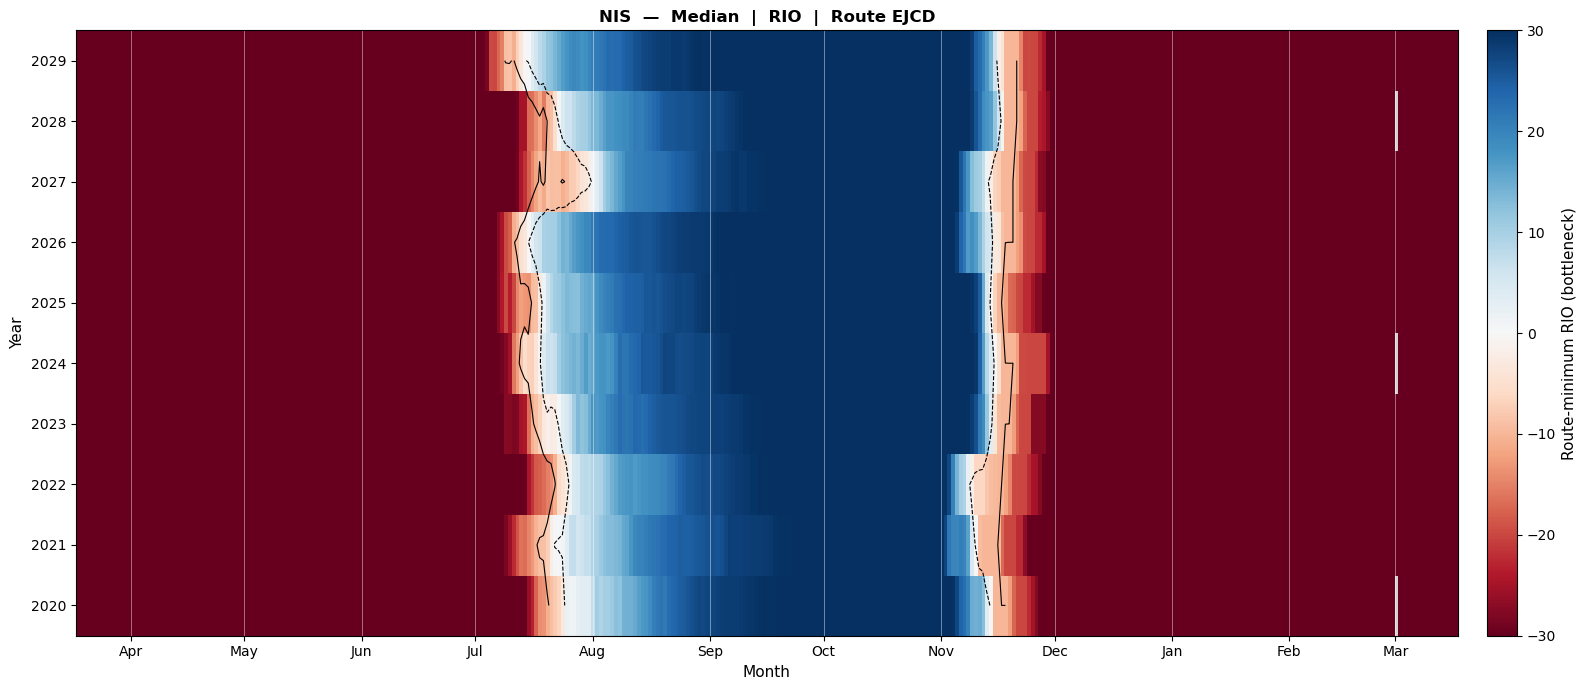

  Saved: ../figures/NIS_routeEJCD_RIO_5_percentile.png


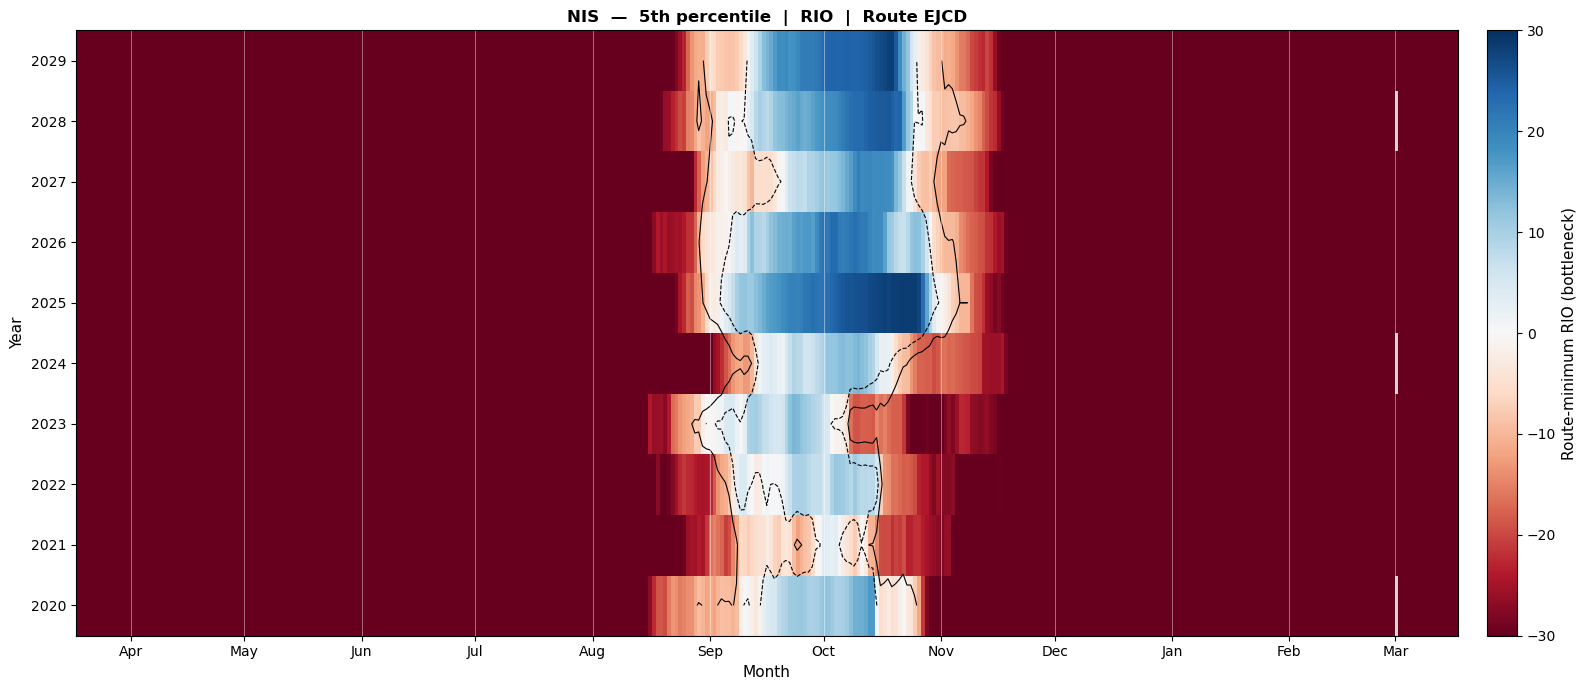

  Saved: ../figures/NIS_routeEJCD_RIO_95_percentile.png


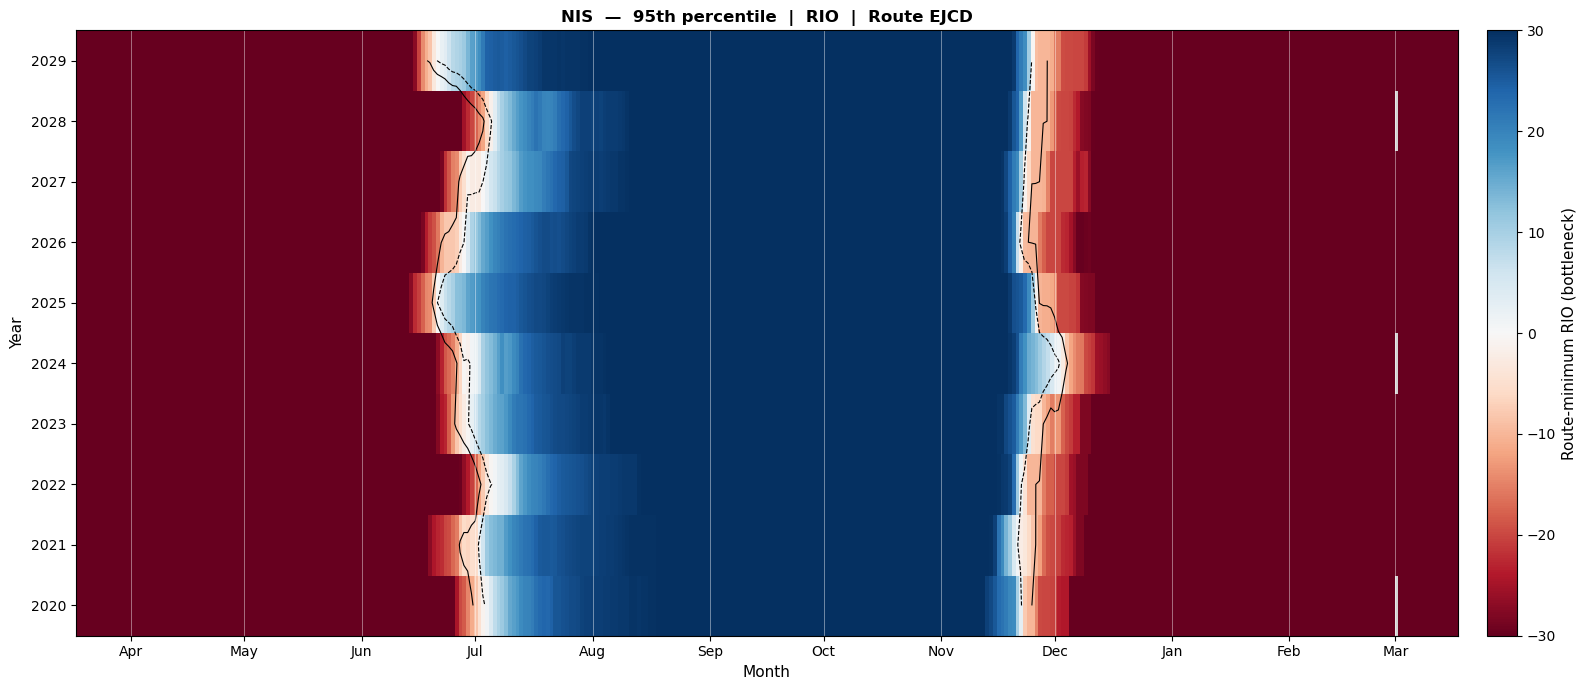

In [10]:
for vessel_class, res in results.items():
    print(f'\nPlotting {vessel_class}  (mode: {plot_mode}) ...')

    if plot_mode == 'transit_time':
        # Transit-time arrays; NaN where impassable
        data_trio = [
            (res['tt_med'],           'Median'),
            (res['tt_5th'],           '5th percentile'),
            (res['tt_95th'],          '95th percentile'),
        ]
    elif plot_mode == 'passability':
        # Passability always uses the route-minimum RIO regardless of rio_summary_method
        data_trio = [
            (res['min_rio_med'],      'Median'),
            (res['min_rio_5th'],      '5th percentile'),
            (res['min_rio_95th'],     '95th percentile'),
        ]
    elif plot_mode == 'RIO':
        # RIO heatmap uses whichever summary method is selected in CONFIG
        data_trio = [
            (res['summary_rio_med'],  'Median'),
            (res['summary_rio_5th'],  '5th percentile'),
            (res['summary_rio_95th'], '95th percentile'),
        ]
    else:
        raise ValueError(f"Unknown plot_mode: '{plot_mode}'")

    for data, stat_label in data_trio:
        make_heatmap(
            data               = data,
            years              = res['years'],
            vessel_class       = vessel_class,
            stat_label         = stat_label,
            plot_mode          = plot_mode,
            route_label        = route_label,
            save_figs          = save_figs,
            output_dir         = output_dir,
            total_dist_nm      = total_dist_nm,
            center_doy         = plot_center_doy,
            rio_summary_method = rio_summary_method,
        )



===== NIS  (Median)  threshold = 0 =====
  Spring  (first day >= threshold; route opens):
    slope = -0.50 days/yr,  R² = 0.087,  RMSE = 4.7 days,  n = 10
  Fall    (last day >= threshold; route closes):
    slope = +0.50 days/yr,  R² = 0.372,  RMSE = 1.9 days,  n = 10
  Saved: ../figures/NIS_RIO_trend_routeEJCD_median.png


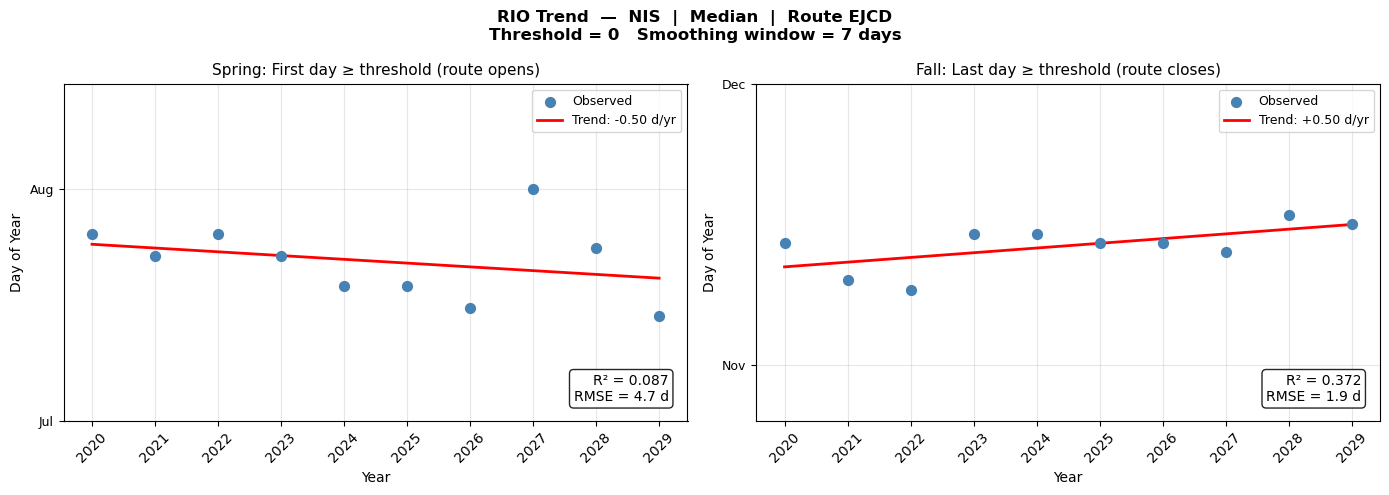


RIO trend analysis complete.


In [11]:
# ---- Trend analysis: RIO spring opening and fall closing ----
# For each vessel class, detects the DOY when the route-summary RIO crosses
# trend_threshold_rio and fits linear trends over the year range.
#
# Crossing logic for RIO (opposite to sea ice):
#   Spring: FIRST day RIO >= threshold  (route opens as ice retreats)
#   Fall:   LAST  day RIO >= threshold  (route closes as ice advances)
#
# Results are stored in _trend_results_rio for use by the optional overlay cell.

_stat_key_map = {
    'median':          'summary_rio_med',
    '5th_percentile':  'summary_rio_5th',
    '95th_percentile': 'summary_rio_95th',
}
_stat_label_map = {
    'median':          'Median',
    '5th_percentile':  '5th percentile',
    '95th_percentile': '95th percentile',
}
if trend_stat not in _stat_key_map:
    raise ValueError(
        f"trend_stat must be 'median', '5th_percentile', or '95th_percentile'; "
        f"got '{trend_stat}'"
    )
_stat_key_trend   = _stat_key_map[trend_stat]
_stat_label_trend = _stat_label_map[trend_stat]

# Storage for optional heatmap overlay cell
_trend_results_rio = {}

for vessel_class, res in results.items():
    print(f'\n===== {vessel_class}  ({_stat_label_trend})  threshold = {trend_threshold_rio} =====')

    avail_years_vc = res['years']
    n_years_vc     = len(avail_years_vc)
    year_arr       = np.array(avail_years_vc, dtype=float)
    data           = res[_stat_key_trend]

    smoothed    = smooth_by_year(data, trend_rolling_window)

    spring_doys = np.full(n_years_vc, np.nan)
    fall_doys   = np.full(n_years_vc, np.nan)
    for yi in range(n_years_vc):
        spring_doys[yi] = find_crossing_doy(
            smoothed[yi], trend_threshold_rio,
            trend_spring_doy_range[0], trend_spring_doy_range[1],
            find='first_above',   # RIO rises above threshold -> route opens
        )
        fall_doys[yi] = find_crossing_doy(
            smoothed[yi], trend_threshold_rio,
            trend_fall_doy_range[0], trend_fall_doy_range[1],
            find='last_above',    # RIO drops below threshold -> route closes
        )

    # Compute and report trends
    print('  Spring  (first day >= threshold; route opens):')
    sp_slope, sp_int, sp_r2, sp_rmse, sp_yrs, sp_doys = compute_trend(
        spring_doys, year_arr)
    if not np.isnan(sp_slope):
        print(f'    slope = {sp_slope:+.2f} days/yr,  '
              f'R\u00b2 = {sp_r2:.3f},  RMSE = {sp_rmse:.1f} days,  n = {len(sp_yrs)}')

    print('  Fall    (last day >= threshold; route closes):')
    fa_slope, fa_int, fa_r2, fa_rmse, fa_yrs, fa_doys = compute_trend(
        fall_doys, year_arr)
    if not np.isnan(fa_slope):
        print(f'    slope = {fa_slope:+.2f} days/yr,  '
              f'R\u00b2 = {fa_r2:.3f},  RMSE = {fa_rmse:.1f} days,  n = {len(fa_yrs)}')

    # Store for overlay
    _trend_results_rio[vessel_class] = {
        'years':       avail_years_vc,
        'spring_doys': spring_doys,
        'fall_doys':   fall_doys,
        'sp_slope': sp_slope, 'sp_int': sp_int, 'sp_r2': sp_r2, 'sp_rmse': sp_rmse,
        'fa_slope': fa_slope, 'fa_int': fa_int, 'fa_r2': fa_r2, 'fa_rmse': fa_rmse,
    }

    # ---- Scatter plot ----
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'RIO Trend  \u2014  {vessel_class}  |  {_stat_label_trend}  |  Route {route_label}\n'
        f'Threshold = {trend_threshold_rio}   '
        f'Smoothing window = {trend_rolling_window} days',
        fontsize=12, fontweight='bold',
    )

    _seasons = [
        ('Spring', 'First day \u2265 threshold (route opens)',  spring_doys,
         sp_slope, sp_int, sp_r2, sp_rmse),
        ('Fall',   'Last day \u2265 threshold (route closes)', fall_doys,
         fa_slope, fa_int, fa_r2, fa_rmse),
    ]

    for ax, (season_name, season_desc, all_doys, slope, intercept, r2, rmse) \
            in zip(axes, _seasons):
        valid_mask = ~np.isnan(all_doys)
        ax.scatter(year_arr[valid_mask], all_doys[valid_mask],
                   color='steelblue', s=50, zorder=3, label='Observed')
        if not np.isnan(slope):
            fit_x = np.array([year_arr[valid_mask].min(), year_arr[valid_mask].max()])
            fit_y = slope * fit_x + intercept
            ax.plot(fit_x, fit_y, 'r-', linewidth=2,
                    label=f'Trend: {slope:+.2f} d/yr')
            stats_text = f'R\u00b2 = {r2:.3f}\nRMSE = {rmse:.1f} d'
            ax.text(0.97, 0.05, stats_text, transform=ax.transAxes,
                    ha='right', va='bottom', fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
        # y-axis: auto-fit each panel to its data range, or use user-specified limits
        if trend_scatter_ylim is not None:
            _ylo, _yhi = trend_scatter_ylim
        else:
            if valid_mask.any():
                _pad = 14  # days of padding on each side
                _ylo = max(0,   float(np.nanmin(all_doys[valid_mask])) - _pad)
                _yhi = min(364, float(np.nanmax(all_doys[valid_mask])) + _pad)
            else:
                _ylo, _yhi = 0, 364
        _vis_ticks  = [d for d in _MONTH_DOY if _ylo <= d <= _yhi]
        _vis_labels = [_MONTH_NAMES[i] for i, d in enumerate(_MONTH_DOY) if _ylo <= d <= _yhi]
        ax.set_yticks(_vis_ticks)
        ax.set_yticklabels(_vis_labels, fontsize=9)
        ax.set_ylim(_ylo, _yhi)
        ax.yaxis.grid(True, alpha=0.3)
        ax.set_title(f'{season_name}: {season_desc}', fontsize=11)
        ax.set_xlabel('Year', fontsize=10)
        ax.set_ylabel('Day of Year', fontsize=10)
        ax.set_xticks(year_arr.astype(int))
        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_figs:
        os.makedirs(trend_output_dir, exist_ok=True)
        _stat_slug_trend = (
            _stat_label_trend.lower()
            .replace(' ', '_').replace('th', '').replace('st', '')
        )
        fname = os.path.join(
            trend_output_dir,
            f'{vessel_class}_RIO_trend_route{route_label}_{_stat_slug_trend}.png',
        )
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'  Saved: {fname}')

    plt.show()
    plt.close(fig)

print('\nRIO trend analysis complete.')


In [ ]:
# ---- Optional: RIO heatmap with trend overlay ----
# Run this cell independently to regenerate RIO heatmaps (for the selected
# trend_stat and plot_mode) with threshold-crossing scatter points and linear
# trend lines overlaid.  Most meaningful when plot_mode = 'RIO'.
#
# Requires the trend analysis cell above to have been run first so that
# _trend_results_rio is populated.  Saved figures get a '_trend' suffix.

if '_trend_results_rio' not in dir() or not _trend_results_rio:
    raise RuntimeError(
        'Run the RIO trend analysis cell above first to populate _trend_results_rio.'
    )

# Resolve stat label (self-contained so this cell can run independently)
_stat_label_overlay_rio = {
    'median':          'Median',
    '5th_percentile':  '5th percentile',
    '95th_percentile': '95th percentile',
}.get(trend_stat, trend_stat)

_stat_key_overlay_rio = {
    'median':          'summary_rio_med',
    '5th_percentile':  'summary_rio_5th',
    '95th_percentile': 'summary_rio_95th',
}[trend_stat]

# Rolled x-axis offset used by make_heatmap
_n_days_overlay_rio    = 365
_start_doy_overlay_rio = (plot_center_doy - _n_days_overlay_rio // 2) % _n_days_overlay_rio


def _to_rolled_rio(doy):
    return (doy - _start_doy_overlay_rio) % _n_days_overlay_rio


for vessel_class, res in results.items():
    trend_res = _trend_results_rio.get(vessel_class)
    if trend_res is None:
        print(f'No trend results for {vessel_class} — skipping.')
        continue

    # Build overlay dicts in heatmap coordinate space (y = year index, x = rolled DOY)
    trend_overlay_arg = {}
    for season_key, doys_key, slope_key, int_key in [
        ('spring', 'spring_doys', 'sp_slope', 'sp_int'),
        ('fall',   'fall_doys',   'fa_slope', 'fa_int'),
    ]:
        all_doys = trend_res[doys_key]
        valid    = ~np.isnan(all_doys)
        trend_overlay_arg[season_key] = {
            'yi':        np.where(valid)[0].astype(float),
            'rolled_x':  np.array([_to_rolled_rio(d) for d in all_doys[valid]]),
            'slope':     trend_res[slope_key],
            'intercept': trend_res[int_key],
        }

    print(f'Plotting {vessel_class}  \u2014  {_stat_label_overlay_rio}  (with trend overlay) ...')
    make_heatmap(
        data               = res[_stat_key_overlay_rio],
        years              = trend_res['years'],
        vessel_class       = vessel_class,
        stat_label         = _stat_label_overlay_rio,
        plot_mode          = plot_mode,
        route_label        = route_label,
        save_figs          = save_figs,
        output_dir         = output_dir,
        total_dist_nm      = total_dist_nm,
        center_doy         = plot_center_doy,
        rio_summary_method = rio_summary_method,
        trend_overlay      = trend_overlay_arg,
    )
